In [1]:
%reload_ext autoreload
%autoreload 2

from metricstudio import Backtest, Filter, Regime, Univ
from metricstudio import patterns as p

# 기본설정

In [2]:
start = "2000-01-01"
end = "2026-02-28"
univ = Univ(market=["KOSPI", 'KOSDAQ'], exclude_reits=True)
bm = p.AllStockPattern(name='모든주식')
bt = Backtest(start, end, benchmark=bm, by='day', univ=univ, db=0)

모든주식 | trim: 100%|██████████| 6447/6447 [00:08<00:00, 722.98it/s]


In [3]:
filter = Filter(market_cap=[5,6,7,8,9,10])#, liquidity=[1,2,3,4,5], order=['market_cap', 'liquidity'])

bb = p.Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=1, bandwidth_max=0.1)
uptrend = p.Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = p.MFI(name='MFI상승').on(trigger='above', threshold=50)
high52w = p.High(name='52주 고가').on(window=240, threshold=0.90, stay_days=1)
amt = p.AmountSurge(name='거래량급증').on(window=20, threshold=1.5)

bb2 = p.Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
uptrend2 = p.Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high2 = p.MFI(name='MFI상승').on(trigger='above', threshold=55)
high52w2 = p.High(name='52주 고가').on(window=240, threshold=0.95, stay_days=1)
amt2 = p.AmountSurge(name='거래량급증').on(window=20, threshold=2)

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 20363.69it/s]
pattern | run: 100%|██████████| 6446/6446 [00:04<00:00, 1512.96it/s]


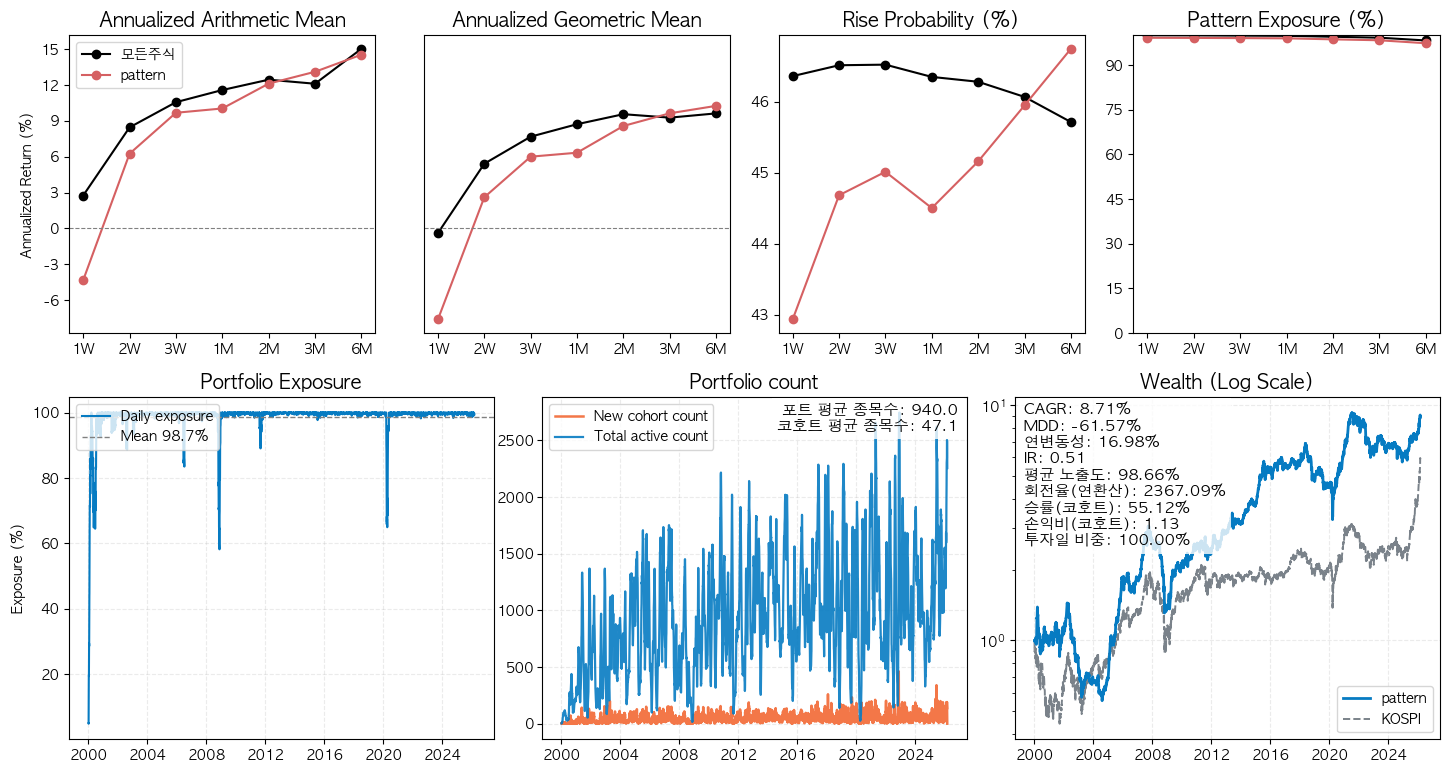

In [12]:
strat = bb.named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 25698.13it/s]
pattern | run: 100%|██████████| 6446/6446 [00:03<00:00, 1753.97it/s]


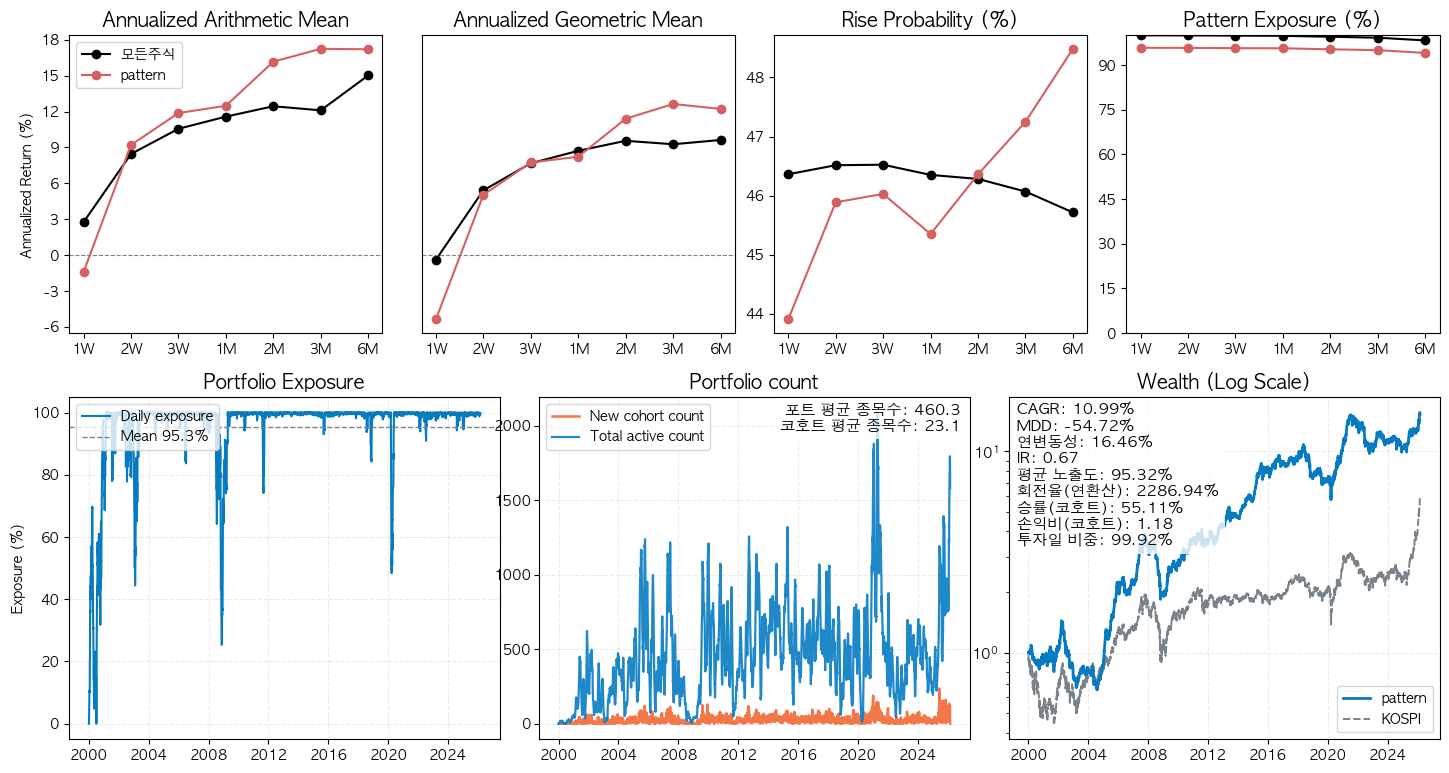

In [5]:
strat = (bb + uptrend).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 46347.45it/s]
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 3466.06it/s]


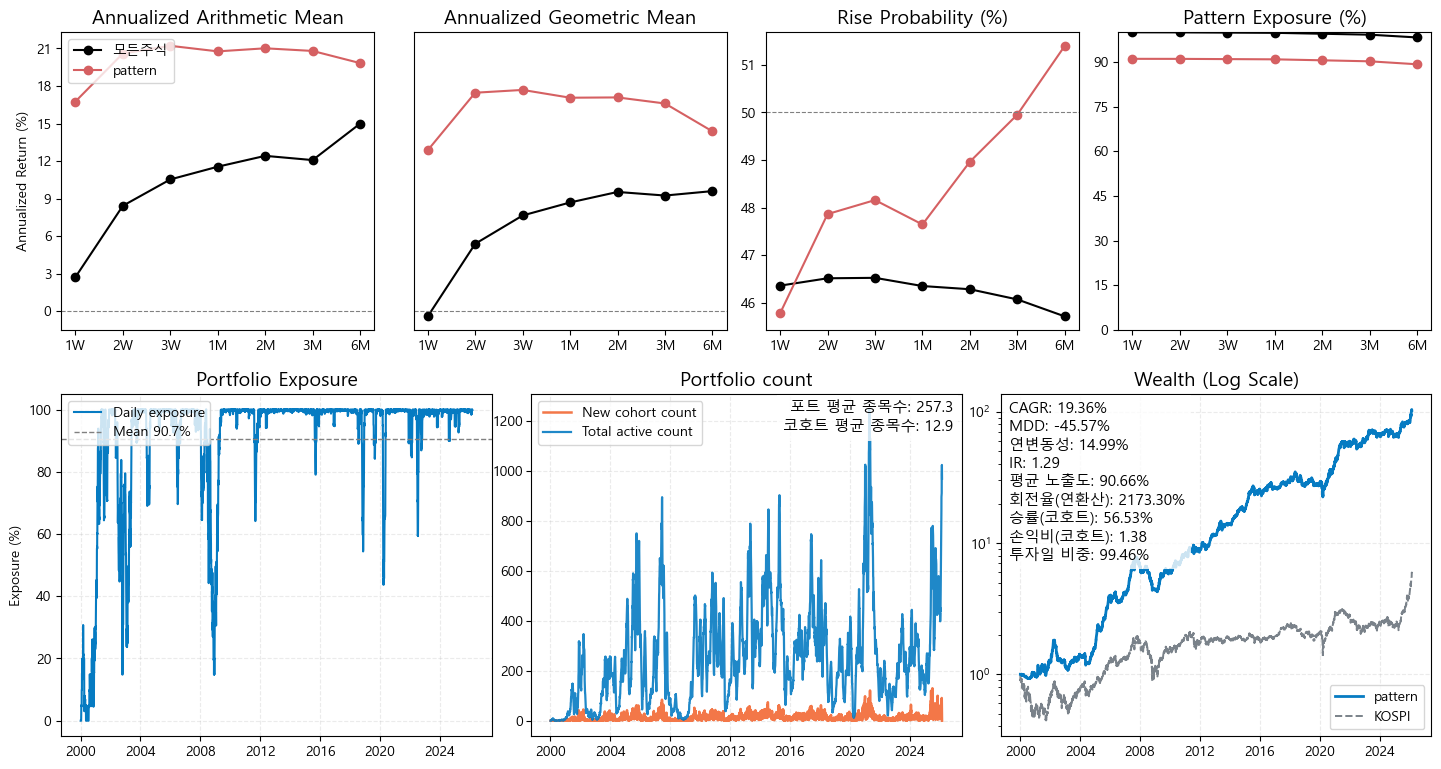

In [12]:
strat = (bb + uptrend + high52w).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 50893.30it/s]
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 3584.91it/s]


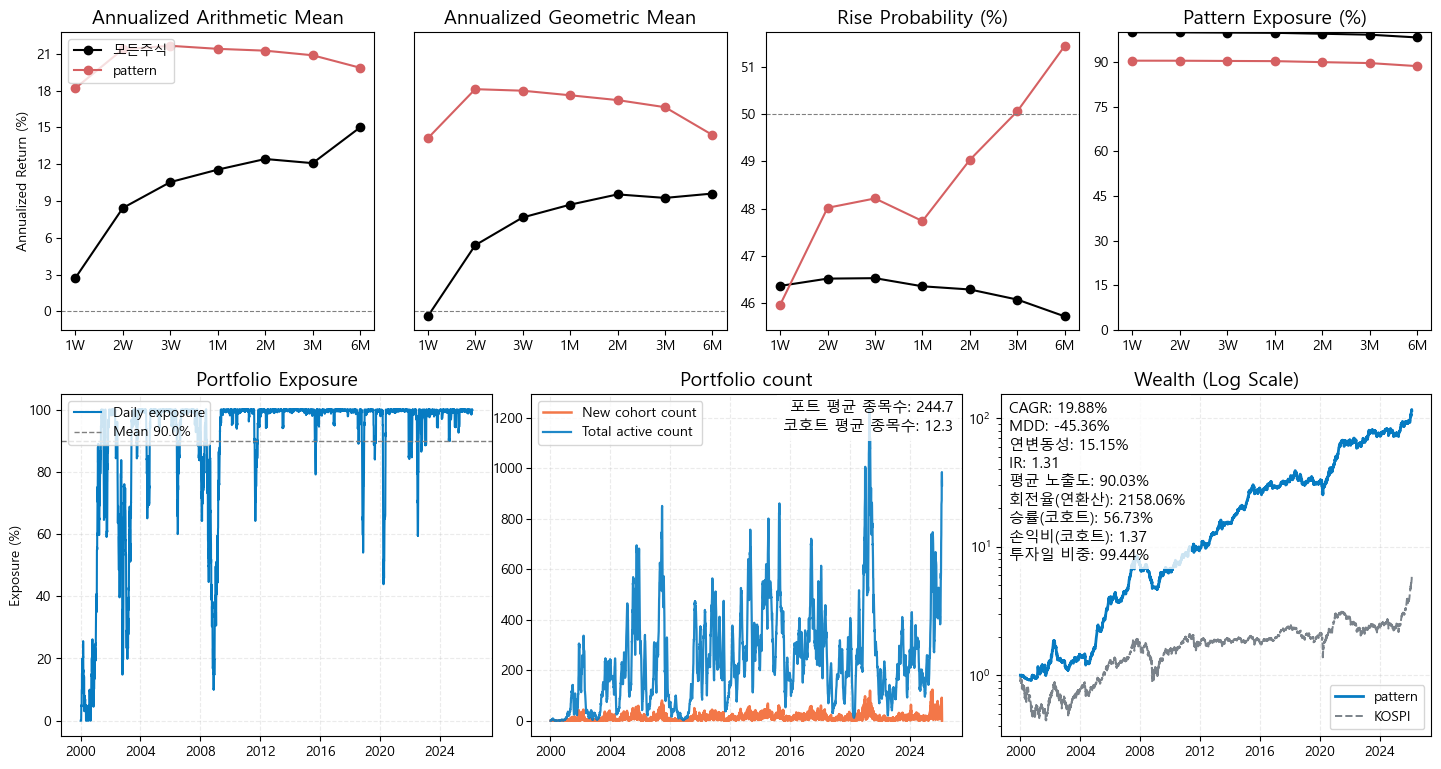

In [13]:
strat = (bb + uptrend + high52w + mfi_high).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 56142.69it/s]
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 3630.58it/s]


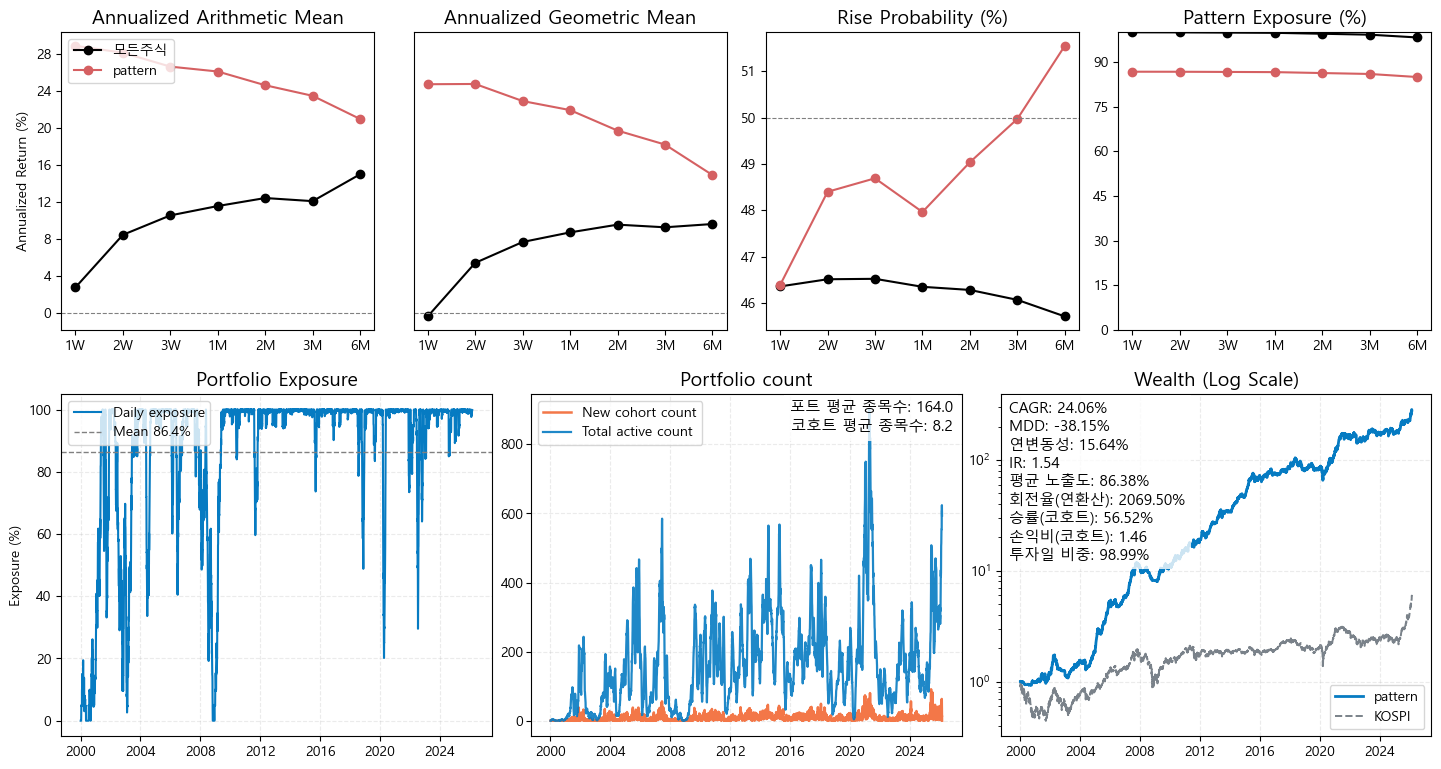

In [14]:
strat = (bb + uptrend + high52w + mfi_high + amt).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 82732.17it/s]
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 5470.57it/s] 


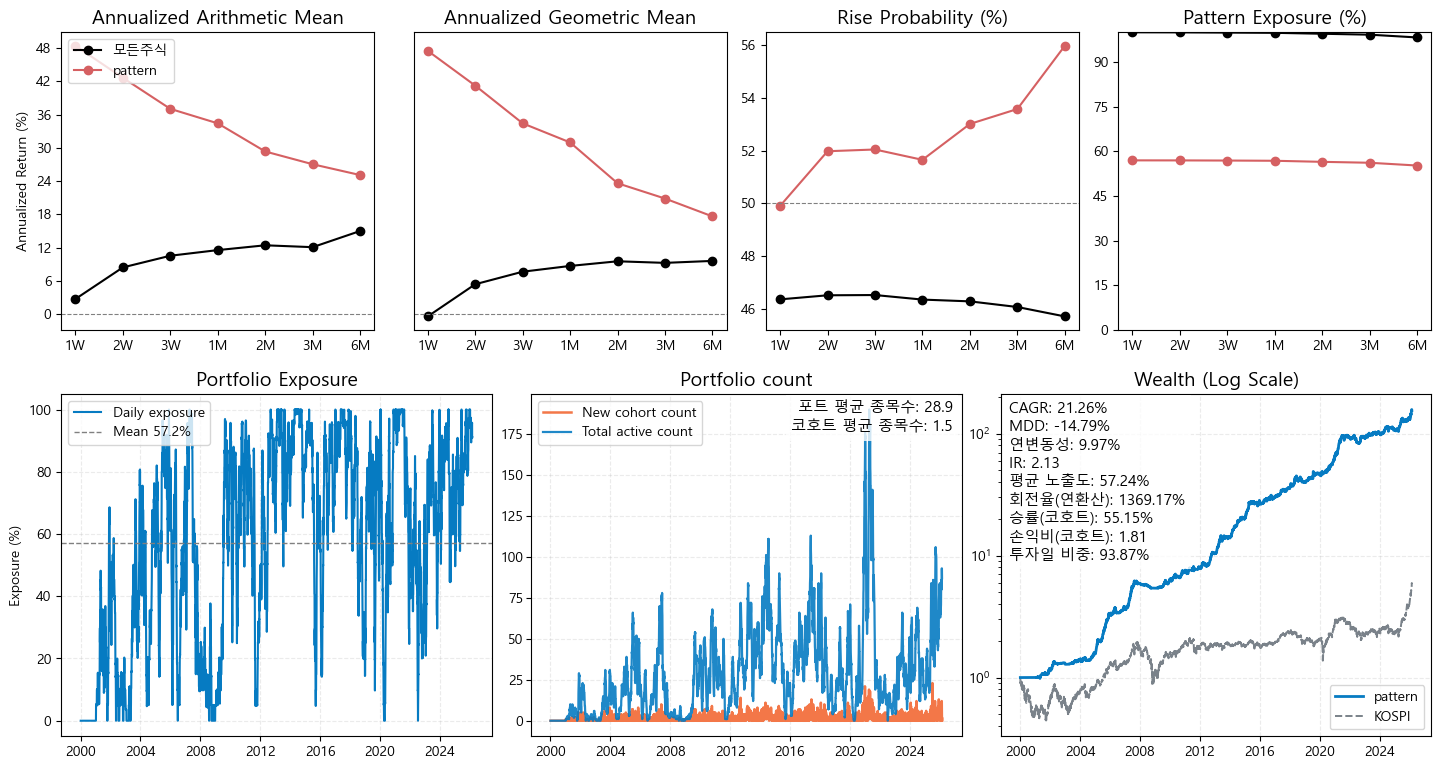

In [15]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)

실행필터 준비 | 필터 마스크: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]  
pattern: 100%|██████████| 6448/6448 [00:07<00:00, 920.63it/s]         
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 3942.34it/s]


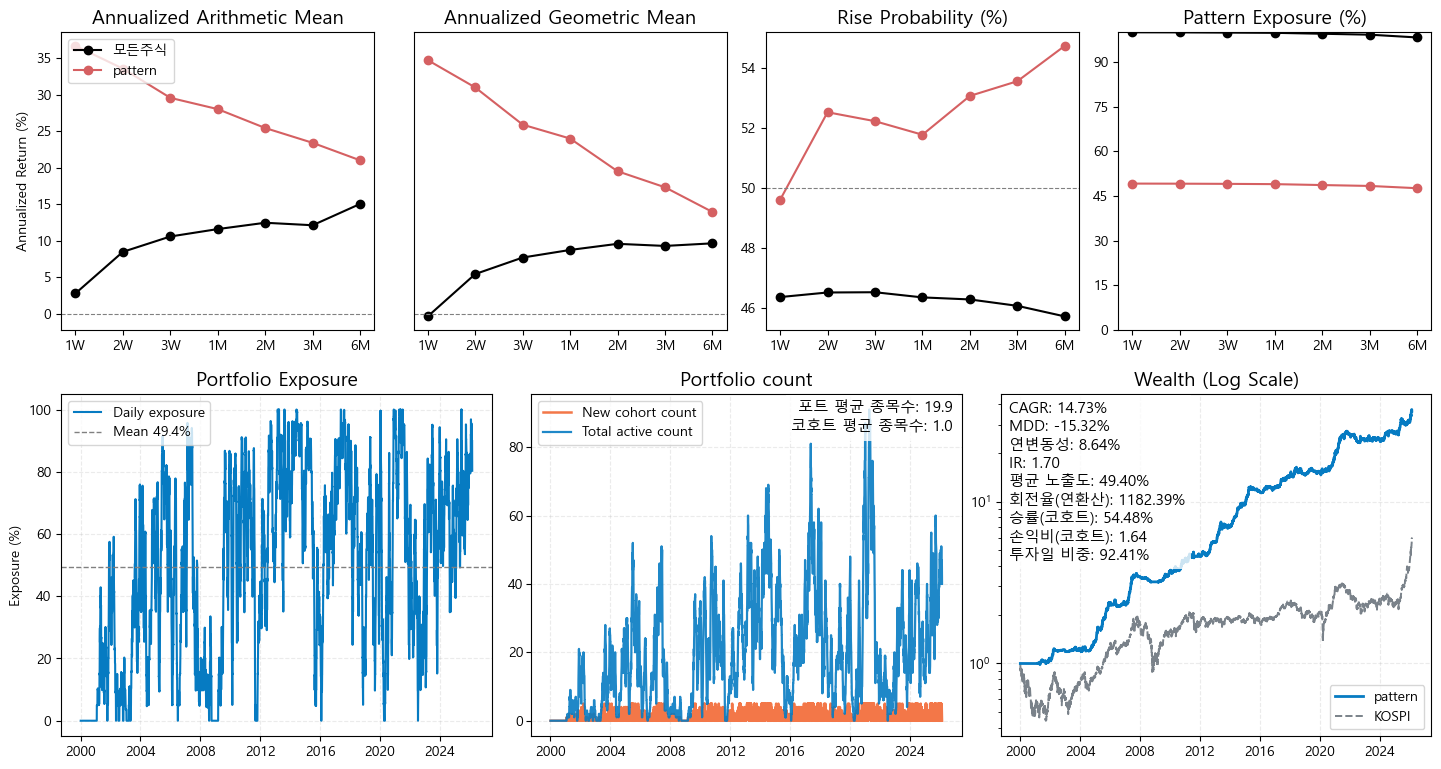

In [39]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern').nmax(5, market_cap=True)
bt.analyze(strat, filter=filter)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)

In [35]:
port = bt.simulator.port_at("2026-02-27").reset_index()
port.to_excel('port.xlsx')#[port.cohort_id == 3666]

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 80867.87it/s]
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 5400.63it/s] 


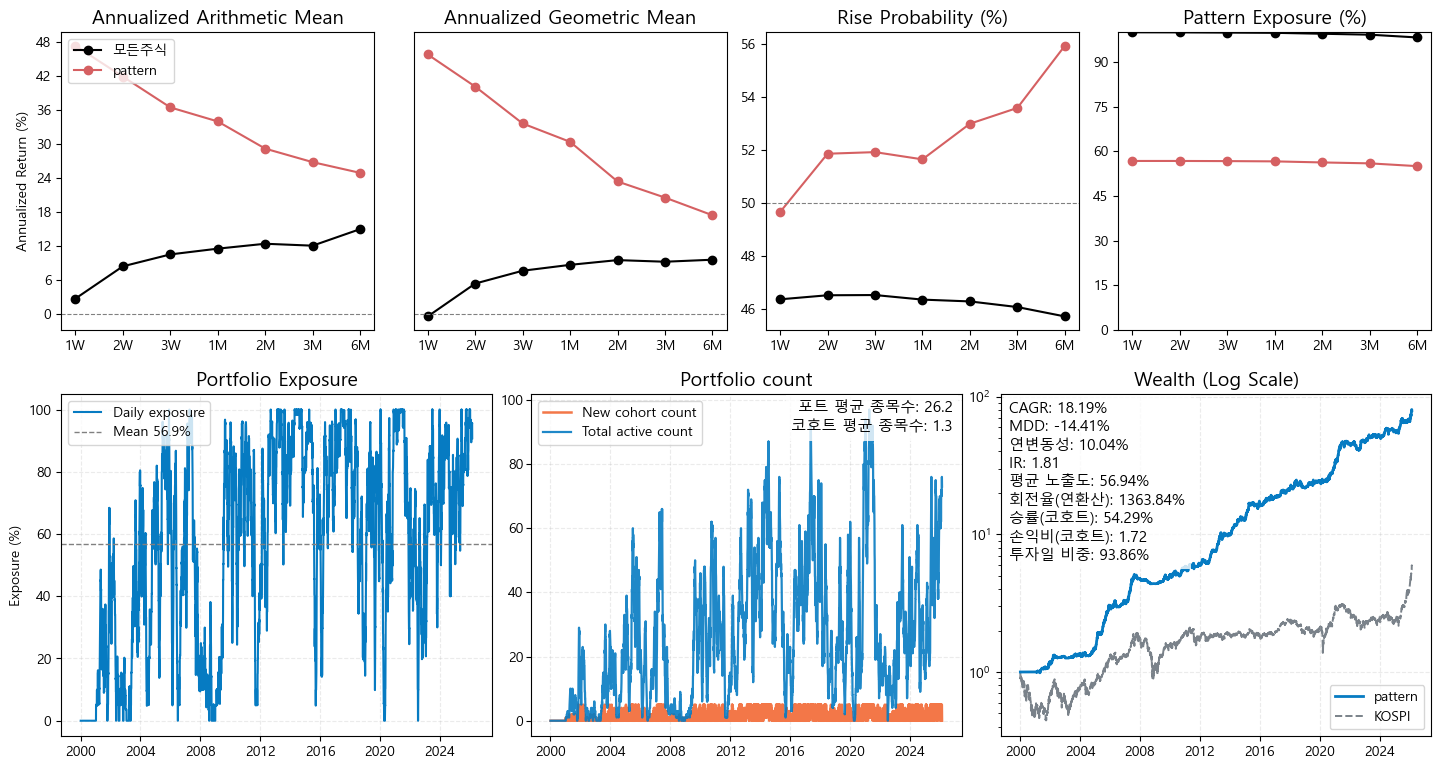

In [23]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern').nmax(5, market_cap=True)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)

pattern | trim: 100%|██████████| 6447/6447 [00:00<00:00, 67109.61it/s]
pattern | run: 100%|██████████| 6446/6446 [00:00<00:00, 9546.98it/s] 


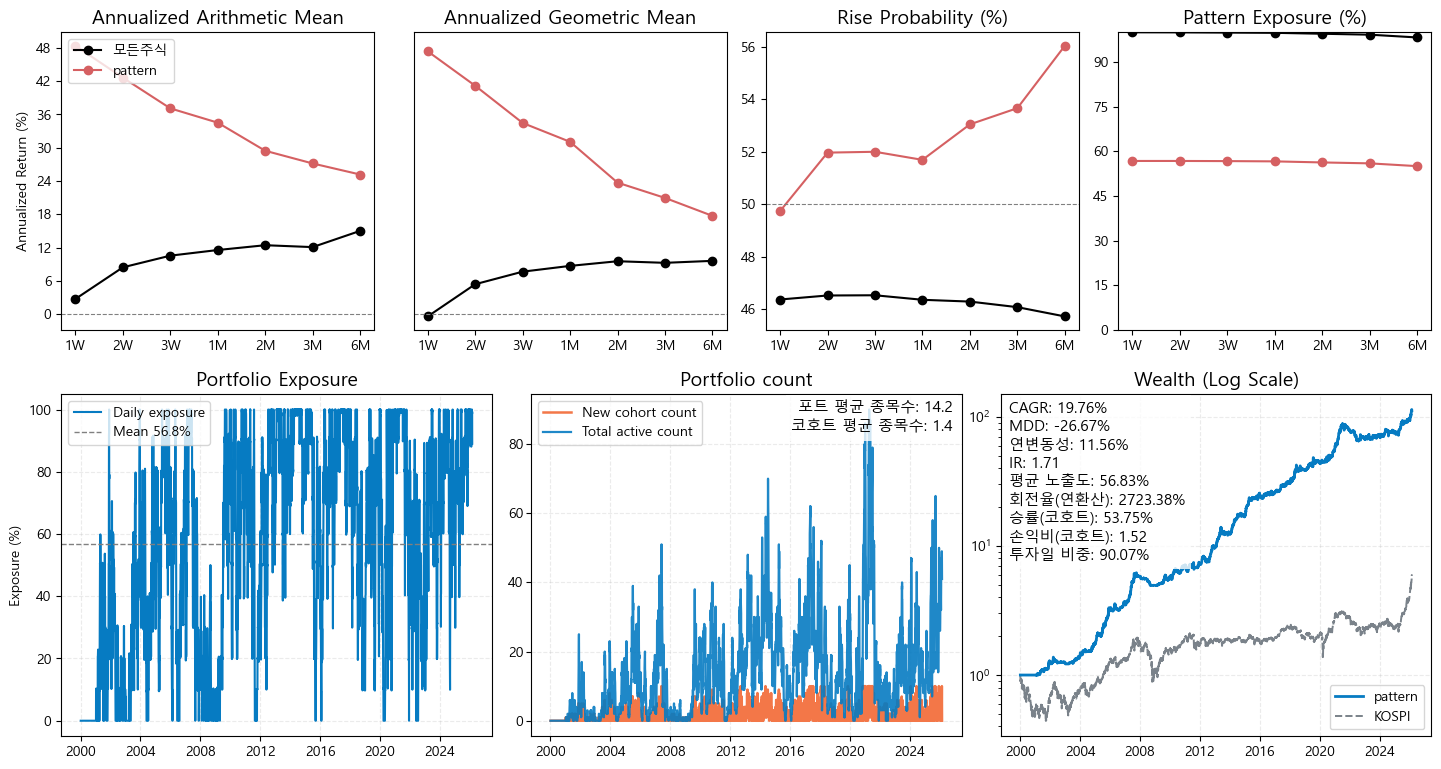

In [24]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern').nmax(10, market_cap=True)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=10, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True, hspace=0.2, wspace=0.5)